In [1]:
import os
# Silences default CPU/GPU logging noise right off the bat
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['AUTOGRAPH_VERBOSITY'] = '0'
os.environ['ABSL_LOGGING_MIN_LOG_LEVEL'] = 'error'

import ctypes
try:
    ctypes.CDLL("libgomp.so.1", mode=ctypes.RTLD_GLOBAL)
except:
    pass

import cv2
import random
import logging
import warnings
import numpy as np
import tensorflow as tf
import absl.logging
from matplotlib import pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Force-silence application logs and warnings
absl.logging.set_verbosity(absl.logging.ERROR)
tf.config.optimizer.set_experimental_options({'layout_optimizer': False})
tf.get_logger().setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

# Installs silently with just a clean progress bar animation
!pip install --quiet segmentation-models

# Bind framework specifications before importing segmentation libraries
os.environ["SM_FRAMEWORK"] = "tf.keras"
import segmentation_models as sm

E0000 00:00:1779532318.067670      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779532318.134803      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779532318.718592      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779532318.718632      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779532318.718635      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779532318.718638      22 computation_placer.cc:177] computation placer already registered. Please check linka

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.4 MB/s eta 0:00:00
Segmentation Models: using `tf.keras` framework.


In [2]:
!ls -lah '/kaggle/input/datasets/azizrixsiev/u-net-semantic-segmentation/Semantic segmentation dataset'
root_dir = '/kaggle/input/datasets/azizrixsiev/u-net-semantic-segmentation'
dataset_dir = '/kaggle/input/datasets/azizrixsiev/u-net-semantic-segmentation/Semantic segmentation dataset'

total 4.0K
drwxr-xr-x 10 nobody nogroup   0 May 23 10:31  .
drwxr-xr-x  3 nobody nogroup   0 May 23 10:31  ..
-rw-r--r--  1 nobody nogroup 548 May 23 10:31  classes.json
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 1'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 2'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 3'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 4'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 5'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 6'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 7'
drwxr-xr-x  4 nobody nogroup   0 May 23 10:31 'Tile 8'


In [3]:
"""Cropping and spliting images, masks"""

images_dataset = []
masks_dataset = []
image_patch_size = 256
BACKBONE = 'resnet34'

def preprocess_data(image_type, extension, dataset):
    for tile_id in range(1, 9):
        for img_id in range(1, 10):
            img = cv2.imread(f"{root_dir}/Semantic segmentation dataset/Tile {tile_id}/{image_type}/image_part_00{img_id}.{extension}", 1)
            
            if img is None: continue

            if image_type == "masks":
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Ensure training images are RGB, not BGR

            # Cropping images (prep before cut)
            h, w, _ = img.shape
            new_h = (h // image_patch_size) * image_patch_size
            new_w = (w // image_patch_size) * image_patch_size
            img = img[:new_h, :new_w]

            # Cutting images
            for y in range(0, img.shape[0], image_patch_size):
                for x in range(0, img.shape[1], image_patch_size):
                    patch = img[y:y + image_patch_size, x:x + image_patch_size, :]
                    dataset.append(patch)

# Process images and masks
preprocess_data('images', 'jpg', images_dataset)
preprocess_data('masks', 'png', masks_dataset)

print(f"Raw images collected: {len(images_dataset)}")
print(f"Raw masks collected: {len(masks_dataset)}")

# Convert to NumPy arrays exactly once
images_dataset = np.array(images_dataset, dtype='float32')
masks_dataset = np.array(masks_dataset)

# Preprocessing tailored to resnet34
preprocess_input = sm.get_preprocessing(BACKBONE)
images_dataset = preprocess_input(images_dataset)

print(f"Images dataset shape: {images_dataset.shape}")
print(f"Masks dataset shape: {masks_dataset.shape}")

Raw images collected: 1305
Raw masks collected: 1305
Images dataset shape: (1305, 256, 256, 3)
Masks dataset shape: (1305, 256, 256, 3)


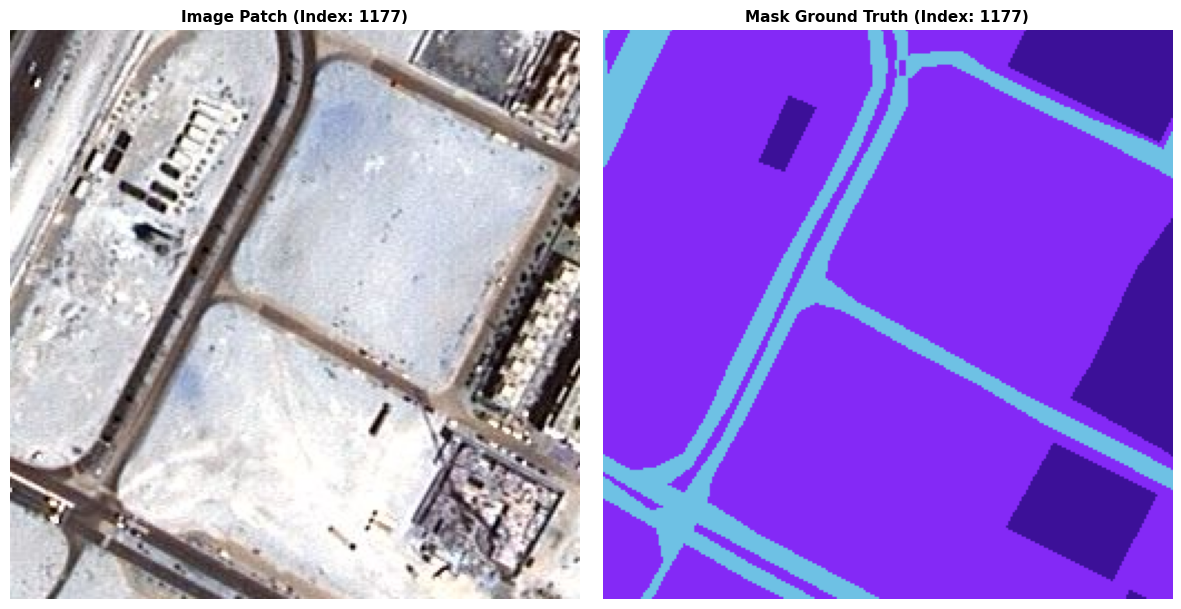

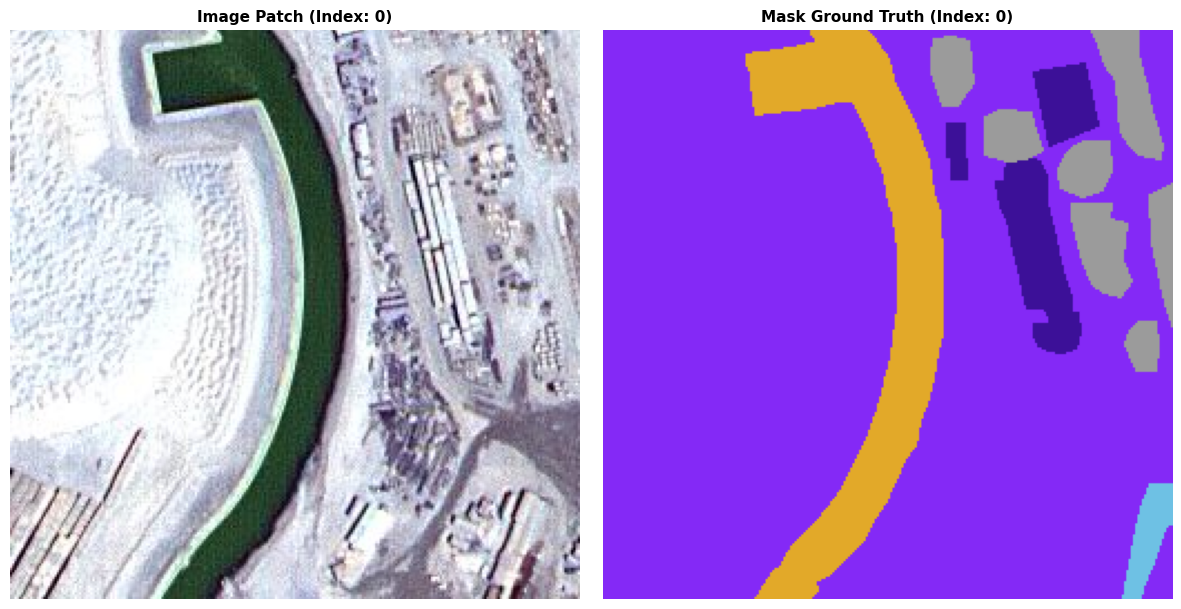

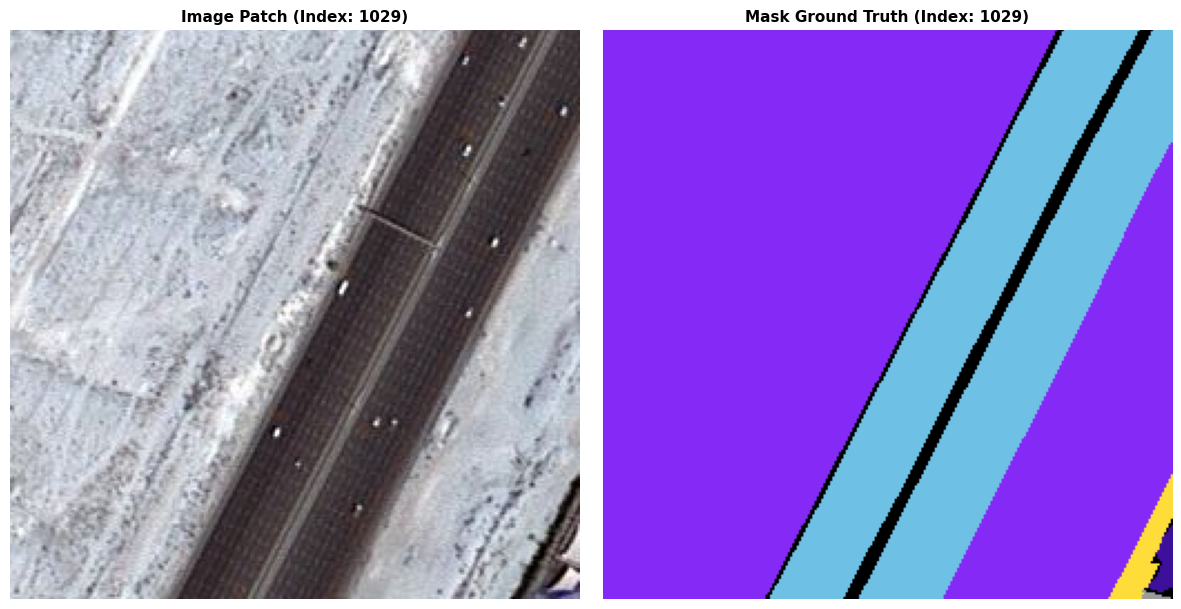

In [4]:
num_samples = 3
random_indices = random.sample(range(len(images_dataset)), num_samples)

for idx in random_indices:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    img_disp = images_dataset[idx]
    if img_disp.min() < 0 or img_disp.max() > 1:
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min() + 1e-8)
        
    plt.imshow(img_disp)
    plt.title(f"Image Patch (Index: {idx})", fontsize=11, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(masks_dataset[idx])
    plt.title(f"Mask Ground Truth (Index: {idx})", fontsize=11, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [5]:
"""Converting labels into rgb values for future model analysis of rgb masks"""

def hex_to_rgb(hex_str):
    hex_str = hex_str.lstrip('#')
    return np.array(tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4)))

building = hex_to_rgb('#3C1098')
land     = hex_to_rgb('#8429F6')
road     = hex_to_rgb('#6EC1E4')
veg      = hex_to_rgb('#FEDD3A')
water    = hex_to_rgb('#E2A929')
unlab    = hex_to_rgb('#9B9B9B')

print(f"Building: {building}")
print(f"Land:     {land}")
print(f"Road:     {road}")
print(f"Veg:      {veg}")
print(f"Water:    {water}")
print(f"Unlabeled:{unlab}")

Building: [ 60  16 152]
Land:     [132  41 246]
Road:     [110 193 228]
Veg:      [254 221  58]
Water:    [226 169  41]
Unlabeled:[155 155 155]


In [6]:
"""Creating label images consisting of numbers between 0-5 for future validation"""

def rgb_to_label(mask):
    label_seg = np.zeros(mask.shape[:2], dtype=np.uint8)
    
    label_seg[np.all(mask == building, axis=-1)] = 0
    label_seg[np.all(mask == land,     axis=-1)] = 1
    label_seg[np.all(mask == road,     axis=-1)] = 2
    label_seg[np.all(mask == veg,      axis=-1)] = 3
    label_seg[np.all(mask == water,    axis=-1)] = 4
    label_seg[np.all(mask == unlab,    axis=-1)] = 5

    return label_seg

num_masks = masks_dataset.shape[0]
h, w, _ = masks_dataset[0].shape
labels = np.zeros((num_masks, h, w, 1), dtype=np.uint8)

for i in range(num_masks):
    labels[i, :, :, 0] = rgb_to_label(masks_dataset[i])

print(f"Labels array shape: {labels.shape}")
print(f"Unique classes: {np.unique(labels)}")

Labels array shape: (1305, 256, 256, 1)
Unique classes: [0 1 2 3 4 5]


In [7]:
print(labels[1, 0:10, 0:10, 0])
print()
print(np.unique(labels))

[[1 5 5 5 5 5 5 5 5 5]
 [1 5 5 5 5 5 5 5 5 5]
 [1 1 5 5 5 5 5 5 5 5]
 [1 1 5 5 5 5 5 5 5 5]
 [1 1 5 5 5 5 5 5 5 5]
 [1 1 1 5 5 5 5 5 5 5]
 [1 1 1 5 5 5 5 5 5 5]
 [1 1 1 5 5 5 5 5 5 5]
 [1 1 1 1 5 5 5 5 5 5]
 [1 1 1 1 5 5 5 5 5 5]]

[0 1 2 3 4 5]


In [8]:
"""Dynamic class weight calculation"""

print("Scanning dataset to calculate class frequencies....")

# Total classes calculation
total_pixels = labels.size
class_counts = np.bincount(labels.flatten().astype(int), minlength=6)

# Calculate inverse frequencies
inverse_frequencies = total_pixels / (6.0 * (class_counts + 1e-7))

# Normalize the weights so they scale smoothly inside the loss function
dynamic_weights = inverse_frequencies / np.sum(inverse_frequencies)

UNLABELED_INDEX = 5
dynamic_weights[UNLABELED_INDEX] = 0.01

dynamic_weights = dynamic_weights / np.sum(dynamic_weights)

print("\n--- V3 CLASS WEIGHTS ---")
class_names = ["Building", "Land", "Road", "Vegetation", "Water", "Unlabeled"]
for i, weight in enumerate(dynamic_weights):
    status = "ANCHORED" if i == UNLABELED_INDEX else "OPTIMIZED"
    print(f"{class_names[i]:<12}: {weight:.4f} ({status})")
print("----------------------------------------------------\n")

Scanning dataset to calculate class frequencies....

--- V3 CLASS WEIGHTS ---
Building    : 0.1835 (OPTIMIZED)
Land        : 0.0471 (OPTIMIZED)
Road        : 0.2688 (OPTIMIZED)
Vegetation  : 0.2455 (OPTIMIZED)
Water       : 0.1931 (OPTIMIZED)
Unlabeled   : 0.0620 (ANCHORED)
----------------------------------------------------



In [9]:
"""Splitting images into 80% for training, 20% for testing and implementing augmentation"""

X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    images_dataset, 
    labels, 
    test_size=0.20, 
    random_state=42
)

total_classes = len(np.unique(labels))
print(f"Total target classes: {total_classes}")
print(f"Training set arrays: {X_train.shape}, Labels: {y_train_labels.shape}")
print(f"Validation set arrays: {X_test.shape}, Labels: {y_test_labels.shape}")

BATCH_SIZE_PER_REPLICA = 16 
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * 1 

def synchronize_augment(image, mask):
    """
    Applying the same augmentation to both image and it's corresponding mask
    """
    # Random Horizontal Flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
        
    # Random Vertical Flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)
        
    # Random 90-degree Rotation
    if tf.random.uniform(()) > 0.5:
        k = tf.random.uniform((), minval=1, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k=k)
        mask = tf.image.rot90(mask, k=k)
        
    return image, mask

def cast_to_one_hot(image, mask):
    """
    Cast into one-hot-encoding
    """
    mask = tf.one_hot(tf.cast(mask, tf.int32), depth=total_classes)
    mask = tf.squeeze(mask, axis=2) 
    return image, mask

"""High performance Pipeline for training data"""

# Pair image with it's label image
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_labels))
# Classic shuffling
train_dataset = train_dataset.shuffle(buffer_size=len(X_train))
# Augment those pair
train_dataset = train_dataset.map(synchronize_augment, num_parallel_calls=tf.data.AUTOTUNE)
# Transform to One-Hot
train_dataset = train_dataset.map(cast_to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
# Pack 16 images and masks into one tensor box (batch) and make sure batches are getting ready by cpu in advance, so gpu does not have to wait
train_dataset = train_dataset.batch(GLOBAL_BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

"""Pipeline for validation"""
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test_labels))
val_dataset = val_dataset.map(cast_to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(GLOBAL_BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

sample_x, sample_y = next(iter(train_dataset))
print("\n  High-performance pipeline compiled successfully:")
print(f"   Batch image tensor shape: {sample_x.shape}")
print(f"   Batch one-hot label shape: {sample_y.shape}")

Total target classes: 6
Training set arrays: (1044, 256, 256, 3), Labels: (1044, 256, 256, 1)
Validation set arrays: (261, 256, 256, 3), Labels: (261, 256, 256, 1)


I0000 00:00:1779532378.292055      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779532378.298265      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



  High-performance pipeline compiled successfully:
   Batch image tensor shape: (16, 256, 256, 3)
   Batch one-hot label shape: (16, 256, 256, 6)


In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.layers import concatenate, BatchNormalization, Dropout, Lambda

In [11]:
def jaccard_coef(y_true, y_pred):
    """
    Calculates the multi-class Jaccard Coefficient (Mean IoU) 
    without letting dominant background classes distort the score
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    total_area = tf.reduce_sum(y_true + y_pred, axis=[1, 2])
    union = total_area - intersection
    
    iou_per_class = (intersection + 1e-7) / (union + 1e-7)
    
    return tf.reduce_mean(iou_per_class)

In [12]:
"""
Because my model will be heavily successfull on detecting "easy" classes that cover most of the land in images, I am implementing total_loss metric, 
so that we can drag the focus of model into trying to predict hard to determine classes (like roads) not easy ones only.
Example: Model is predicting water and land easily but poorly works with roads, simple accuracy function will output 90%+ accuracy
if images are mostly water or land.
"""

import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'
import tensorflow as tf
import segmentation_models as sm

# Dynamic class weights based on the frequency
CLASS_WEIGHTS_LIST = dynamic_weights.tolist()

# Punish model for wrong shape prediction (specifically harsh for hard to predict classes)
dice_loss = sm.losses.DiceLoss(class_weights=CLASS_WEIGHTS_LIST)

# Set prioty for hard to determine classes
focal_loss = sm.losses.CategoricalFocalLoss(alpha=CLASS_WEIGHTS_LIST, gamma=2.0)

# Both combined
def total_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + (1.0 * focal_loss(y_true, y_pred))

print("Total loss function set up successfully")

Total loss function set up successfully



Number of devices: 2
85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model with imagenet weights and resnet34 architecture backbone is built successfully
Model compiled and ready to use
Epoch 1/100


I0000 00:00:1779532416.422170      81 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779532417.036770      80 cuda_dnn.cc:529] Loaded cuDNN version 91002


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.4459 - jaccard_coef: 0.1024 - loss: 1.9490
Epoch 1: val_jaccard_coef improved from -inf to 0.17344, saving model to model_v2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 63s 439ms/step - accuracy: 0.4484 - jaccard_coef: 0.1031 - loss: 1.9483 - val_accuracy: 0.6746 - val_jaccard_coef: 0.1734 - val_loss: 2.0309 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.7600 - jaccard_coef: 0.2176 - loss: 1.8614
Epoch 2: val_jaccard_coef improved from 0.17344 to 0.27241, saving model to model_v2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 330ms/step - accuracy: 0.7600 - jaccard_coef: 0.2177 - loss: 1.8613 - val_accuracy: 0.5385 - val_jaccard_coef: 0.2724 - val_loss: 2.4835 - learning_rate: 0.0010
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7901 - jaccard_coef: 0.2484 - loss: 1.8306
Epoch 3: val_jaccard_coef did not improve from 0.27241
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 306ms/step - accuracy: 0.7900 - j

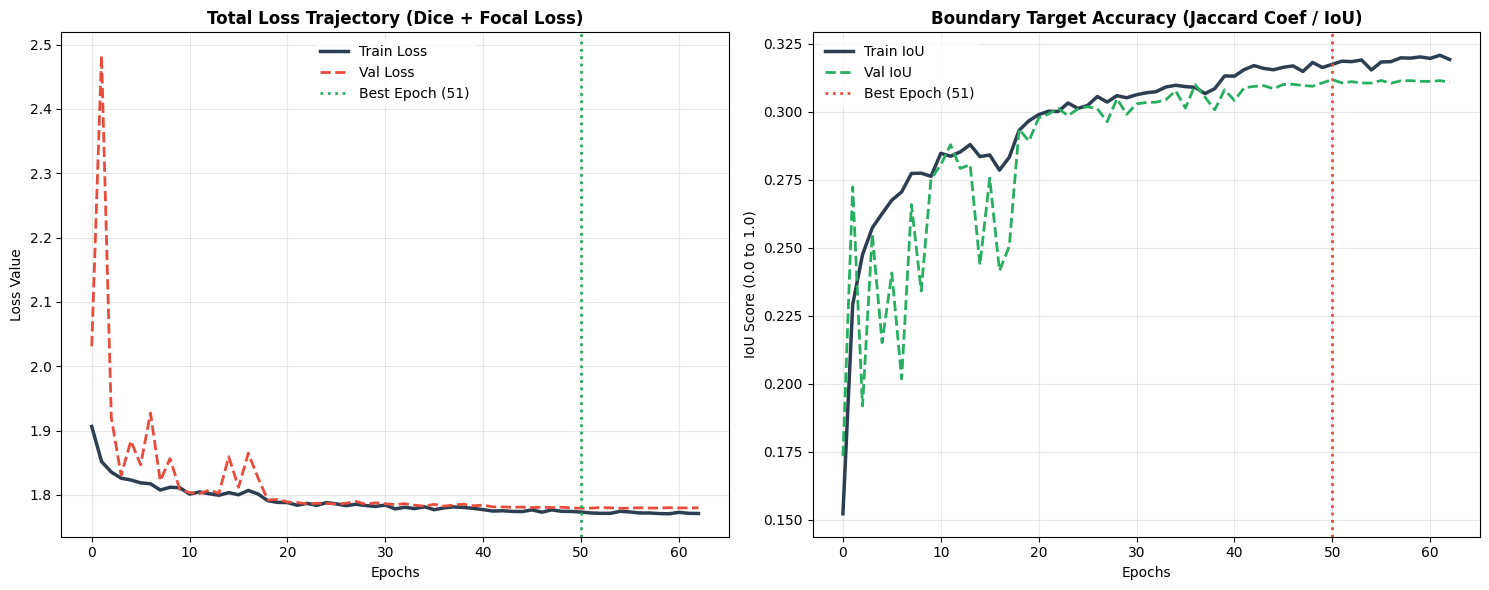

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

tf.keras.backend.clear_session()

strategy = tf.distribute.MirroredStrategy()
print(f"\nNumber of devices: {strategy.num_replicas_in_sync}")

metrics = [jaccard_coef, 'accuracy']
TOTAL_CLASSES = 6  
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_CHANNELS = 3 

early_stopping = EarlyStopping(
    monitor='val_jaccard_coef', 
    patience=12,               
    mode='max', 
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=6,                        
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='model_v2.keras',
    monitor='val_jaccard_coef', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

# Compile model and run training on both GPUs
with strategy.scope():
    
    model = sm.Unet(
        backbone_name=BACKBONE, 
        encoder_weights='imagenet', 
        classes=TOTAL_CLASSES, 
        activation='softmax',
        input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)
    )
    print("Model with imagenet weights and resnet34 architecture backbone is built successfully")

    model.compile(
        optimizer="adam", 
        loss=total_loss, 
        metrics=metrics
    )
    print("Model compiled and ready to use")
    
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=100,
        callbacks=[early_stopping, lr_scheduler, checkpoint],
        verbose=1
    )

best_epoch = early_stopping.best_epoch if hasattr(early_stopping, 'best_epoch') else len(history.history['loss']) - 1

iou_metric_name = 'jaccard_coef'
val_iou_metric_name = 'val_jaccard_coef'
peak_iou = history.history[val_iou_metric_name][best_epoch]

print("\n" + "="*45)
print("         VERSION 2 PERFORMANCE SUMMARY        ")
print("="*45)
print(f" Total Epochs Executed:   {len(history.history['loss'])}")
print(f" Optimal Epoch Restored:  Epoch {best_epoch + 1}")
print(f" Best Validation Loss:    {history.history['val_loss'][best_epoch]:.4f}")
print(f" Peak Jaccard Coef (IoU): {peak_iou:.4f}")
print(f" Final Pixel Accuracy:    {history.history['val_accuracy'][best_epoch]:.4f}")
print("-"*45)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#2c3e50', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2, linestyle='--')
plt.axvline(x=best_epoch, color='#27ae60', linestyle=':', linewidth=2, label=f'Best Epoch ({best_epoch+1})')
plt.title('Total Loss Trajectory (Dice + Focal Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history[iou_metric_name], label='Train IoU', color='#2c3e50', linewidth=2.5)
plt.plot(history.history[val_iou_metric_name], label='Val IoU', color='#27ae60', linewidth=2, linestyle='--')
plt.axvline(x=best_epoch, color='#e74c3c', linestyle=':', linewidth=2, label=f'Best Epoch ({best_epoch+1})')
plt.title('Boundary Target Accuracy (Jaccard Coef / IoU)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('IoU Score (0.0 to 1.0)', fontsize=10)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Generating true-color inference for 10 random satellite patches...


W0000 00:00:1779533873.107594      22 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Conv2D" attr { key: "T" value { type: DT_FLOAT } } attr { key: "data_format" value { s: "NHWC" } } attr { key: "dilations" value { list { i: 1 i: 1 i: 1 i: 1 } } } attr { key: "explicit_paddings" value { list { } } } attr { key: "padding" value { s: "VALID" } } attr { key: "strides" value { list { i: 1 i: 2 i: 2 i: 1 } } } attr { key: "use_cudnn_on_gpu" value { b: true } } inputs { dtype: DT_FLOAT shape { dim { } dim { size: 262 } dim { size: 262 } dim { size: 3 } } } inputs { dtype: DT_FLOAT shape { dim { size: 7 } dim { size: 7 } dim { size: 3 } dim { size: 64 } } } device { type: "GPU" vendor: "NVIDIA" model: "Tesla T4" frequency: 1590 num_cores: 40 environment { key: "architecture" value: "7.5" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90300" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 4194304 shared_memory_size_per_multi

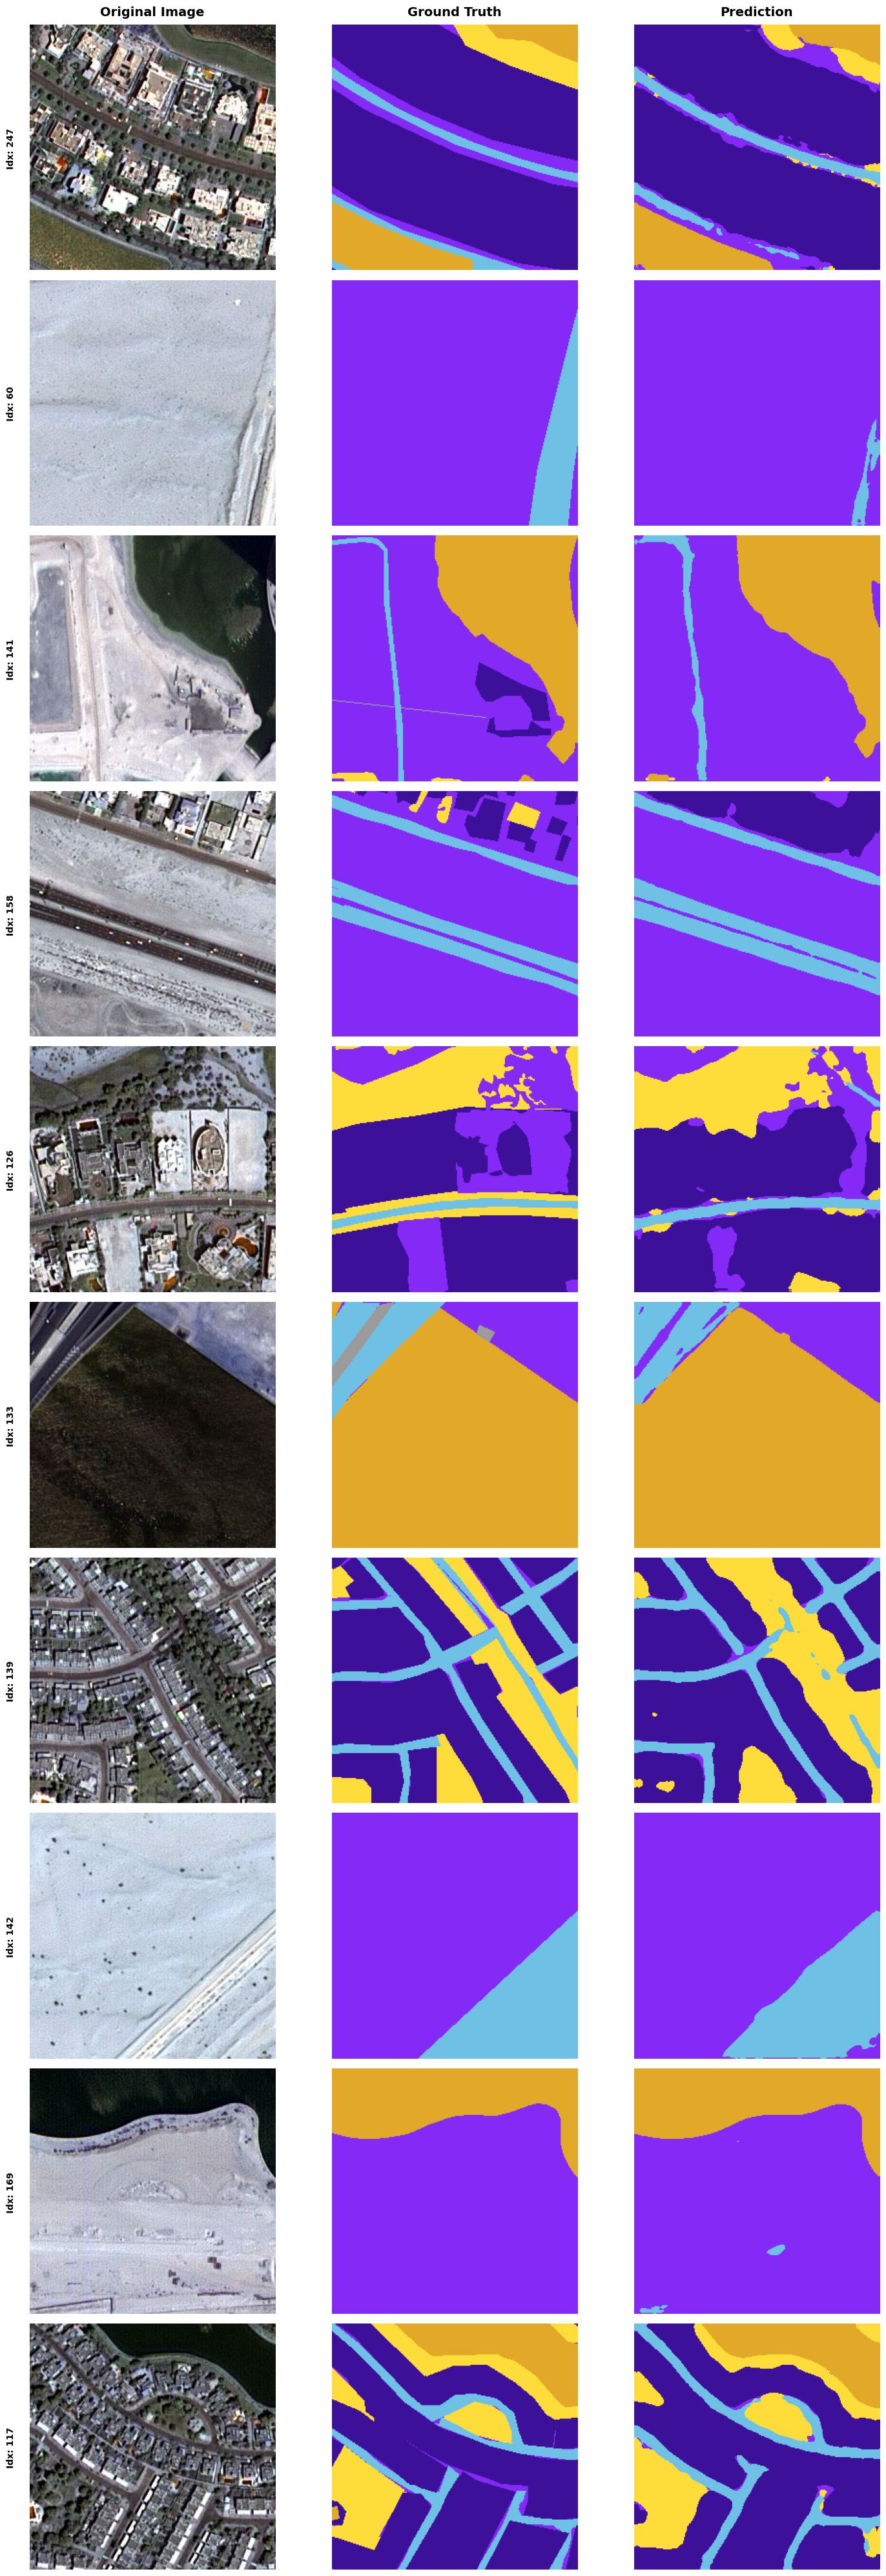

In [14]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import os
import random
import numpy as np
import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

def visualize_predictions(model, x_test, y_test, num_samples=10):
    rgb_map = np.array([
        [60,  16, 152],  # 0: Building (#3C1098)
        [132, 41, 246],  # 1: Land (#8429F6)
        [110, 193, 228], # 2: Road (#6EC1E4)
        [254, 221,  58], # 3: Vegetation (#FEDD3A)
        [226, 169,  41], # 4: Water (#E2A929)
        [155, 155, 155]  # 5: Unlabeled (#9B9B9B)
    ], dtype=np.uint8)

    random_indices = random.sample(range(len(x_test)), num_samples)
    fig, axes = plt.subplots(nrows=num_samples, ncols=3, figsize=(15, num_samples * 4))
    
    print(f"Generating true-color inference for {num_samples} random satellite patches...")
    
    for row_idx, test_idx in enumerate(random_indices):
        test_img = x_test[test_idx]
        ground_truth = y_test[test_idx]
        
        display_img = (test_img * 255).astype(np.uint8) if test_img.max() <= 1.0 else test_img.astype(np.uint8)
        
        test_img_input = np.expand_dims(test_img, 0)
        prediction = model.predict(test_img_input, verbose=0)
        predicted_mask_ints = np.argmax(prediction.squeeze(), axis=-1)
        
        if len(ground_truth.shape) == 3 and ground_truth.shape[-1] > 1:
            true_mask_ints = np.argmax(ground_truth, axis=-1)
        else:
            true_mask_ints = np.squeeze(ground_truth).astype(int)
        
        true_mask_rgb = rgb_map[true_mask_ints]
        predicted_mask_rgb = rgb_map[predicted_mask_ints]
        
        ax_img = axes[row_idx, 0]
        ax_img.imshow(display_img) 
        ax_img.axis('off')
        if row_idx == 0:
            ax_img.set_title("Original Image", fontsize=14, fontweight='bold', pad=10)
        ax_img.text(-15, test_img.shape[0]//2, f"Idx: {test_idx}", 
                    va='center', ha='right', fontsize=10, fontweight='bold', rotation=90)

        ax_true = axes[row_idx, 1]
        ax_true.imshow(true_mask_rgb)
        ax_true.axis('off')
        if row_idx == 0:
            ax_true.set_title("Ground Truth", fontsize=14, fontweight='bold', pad=10)

        ax_pred = axes[row_idx, 2]
        ax_pred.imshow(predicted_mask_rgb)
        ax_pred.axis('off')
        if row_idx == 0:
            ax_pred.set_title("Prediction", fontsize=14, fontweight='bold', pad=10)
            
    plt.tight_layout()
    plt.show()

visualize_predictions(model, X_test, y_test_labels, num_samples=10)